In [1]:
import numpy as np
import pickle as pkl
from dataclasses import dataclass
import sklearn
import matplotlib.pyplot as plt
from collections import Counter
from utils.utils import plotClassification

In [2]:
def Linear(gamma: float=None, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        #Vectorize scalar product
        if len(x.shape) == len(y.shape) and len(x.shape) > 1:
            if on_diagonal:
                return np.einsum('ij, ij -> i', x, y)
            return np.einsum('ij, kj -> ik', x, y)
        return x @ y.T
    return kernel

def RBF(gamma: float = 1, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        if on_diagonal:
            #Distance between paired points
            expo=-(np.sum((x - y)**2, axis = -1))/(2*gamma) #Sum along the data dimension
        else:
            #Vectorized difference
            expo = -(np.sum((x[:,None,:] - y[None,:,:])**2, axis = -1))/(2*gamma) #Sum along the data dimension
        return np.exp(expo)
    return kernel

def poly(gamma: int, c:float=1):
    assert type(gamma)==int, "Power parameter should be an integer."
    lin=Linear()
    def kernel(x, y, on_diagonal: bool=False):
        return np.pow((c + lin(x, y, on_diagonal)), gamma)
    return kernel

def sigmoid(gamma: float=1, c: float=1):
    lin=Linear()
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        return np.tanh(gamma*lin(x, y, on_diagonal) + c)
    return kernel

In [3]:
file = open('datasets/classification_datasets', 'rb')
datasets = pkl.load(file)
file.close()
dataset = datasets['dataset_3']

# Kernel Logistic Regression

### Weighted Kernel Ridge Regression

In [4]:
class WKernelRR:

    def __init__(self, kernel: callable, lmbda: float, weight: list[float] = None):
        self.lmbda = lmbda
        self.kernel = kernel
        self.alpha = None 
        self.b = None
        self.support = None
        self.type='ridge'
        self.weight = weight

    def fit(self, X, y):

        N = X.shape[0] #Number of samples
        X = X.reshape(N,-1)
        
        if isinstance(self.weight, type(None)):
            self.weight = np.ones(N)
        elif isinstance(self.weight, list) or isinstance(self.weight, np.ndarray):
            assert all(self.weight > 0), "The weights of the matrix should all be positive."
            self.weight = np.sqrt(self.weight)

        self.support = X

        if isinstance(self.kernel, type(Linear)) or isinstance(self.kernel, type(RBF)):
            K = self.kernel(X,X)
        elif isinstance(self.kernel, list) or isinstance(self.kernel, np.ndarray):
            K = self.kernel
        K_ridge = np.diag(self.weight) @ K @ np.diag(self.weight) + self.lmbda*N/(2*self.weight)*np.eye(N)
        self.alpha = np.diag(self.weight) @ np.linalg.solve(K_ridge,self.weight*y)

    ### Implementation of the separting function $f$
    def regression_function(self,x):
        # Input : matrix x of shape N data points times d dimension
        # Output: vector of size N
        N = x.shape[0]
        x = x.reshape(N,-1)
        return self.kernel(x, self.support) @ self.alpha

    def predict(self, X):
        return self.regression_function(X)

In [5]:
class KLogisticRegression:
    def __init__(self, kernel, lmbda: float = 1e-3, epsilon: float = 1e-6):
        self.kernel = kernel
        self.lmbda = lmbda
        self.alpha = None

        self.support_train = None
        self.epsilon = epsilon

    @staticmethod
    def sigmoid(x):
        return 1/(1 + np.exp(-x))

    @staticmethod
    def derivative_logistic(x):
        return -KLogisticRegression.sigmoid(-x)

    @staticmethod
    def update_weight(x):
        return KLogisticRegression.sigmoid(x)*KLogisticRegression.sigmoid(-x)
    
    def update_coeff(self, Kern: np.ndarray, y: np.ndarray):
        m = Kern @ self.alpha
        weight = self.update_weight(m)
        z = m + y/self.sigmoid(y*m)
        return weight, z

    def fit(self, X: np.ndarray, y: np.ndarray):
        N = X.shape[0] #Number of samples
        self.support_train = X

        alpha_prev = np.inf
        self.alpha = np.zeros(N)

        count_max = 1e4
        k = 0
        Kern = self.kernel(X,X) #Gram matrix
        delta = np.linalg.norm(self.alpha - alpha_prev)
        while delta > self.epsilon and k < count_max:
            weight, z = self.update_coeff(Kern, y)
            model = WKernelRR(Kern, self.lmbda, weight)
            model.fit(X,z)
            alpha_prev = self.alpha
            self.alpha = model.alpha
            delta = np.linalg.norm(self.alpha - alpha_prev)
            k += 1

    def predict(self, X: np.ndarray, y: np.ndarray = None):
        if isinstance(y, type(None)):
            return self.sigmoid(X) >= 1/2

        f_x = self.kernel(X, self.support_train) @ self.alpha
        output = np.where(self.sigmoid(f_x) >= 1/2, 1, -1)
        precision = np.count_nonzero(output == y)/len(y)
        return output, precision
    
    @staticmethod
    def evaluate(y_test: np.ndarray, y_pred: np.ndarray):
        assert len(y_test) == len(y_pred), "Both array should be the same size."
        f1 = sklearn.metrics.f1_score(y_test, y_pred)
        precision = np.count_nonzero(y_test == y_pred)/len(y_pred)
        return f1, precision

The f1_score is 1.00, and the classifier's precision is 100.00%


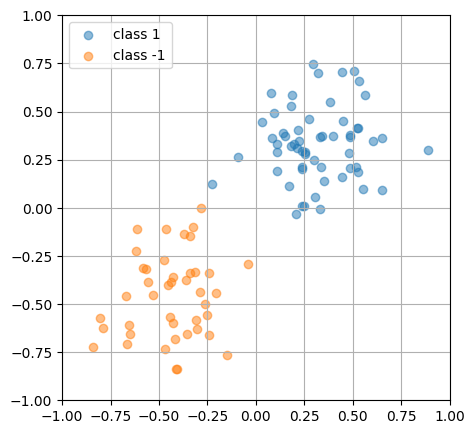

In [6]:
dataset = 'dataset_1'
X_train = np.copy(datasets[dataset]['train']['x'])
y_train = np.copy(datasets[dataset]['train']['y'])

X_test = np.copy(datasets[dataset]['test']['x'])
y_test = np.copy(datasets[dataset]['test']['y'])

kernel = Linear()

Klog = KLogisticRegression(kernel)
Klog.fit(X_train, y_train)

y_pred, precision = Klog.predict(X_test, y_test)

f1_score, precision = Klog.evaluate(y_pred, y_test)
print(f"The f1_score is {f1_score:.2f}, and the classifier's precision is {100*precision:.2f}%")

fig, ax = plt.subplots(1,1, figsize=(5, 5))
plotClassification(X_train, y_train, ax=ax)

The f1_score is 0.85, and the classifier's precision is 85.00%


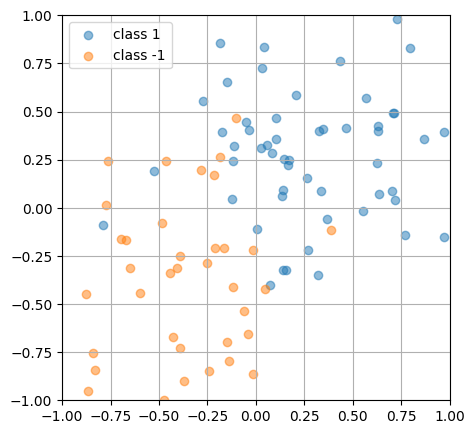

In [7]:
dataset = 'dataset_2'
X_train = np.copy(datasets[dataset]['train']['x'])
y_train = np.copy(datasets[dataset]['train']['y'])

X_test = np.copy(datasets[dataset]['test']['x'])
y_test = np.copy(datasets[dataset]['test']['y'])

kernel = RBF(gamma = 2)

Klog = KLogisticRegression(kernel)
Klog.fit(X_train, y_train)

y_pred, precision = Klog.predict(X_test, y_test)

f1_score, precision = Klog.evaluate(y_pred, y_test)
print(f"The f1_score is {f1_score:.2f}, and the classifier's precision is {100*precision:.2f}%")

fig, ax = plt.subplots(1,1, figsize=(5, 5))
plotClassification(X_train, y_train, ax=ax)

The f1_score is 0.91, and the classifier's precision is 91.00%


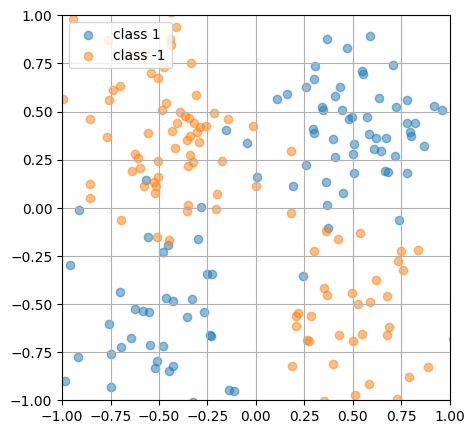

In [8]:
dataset = 'dataset_3'
X_train = np.copy(datasets[dataset]['train']['x'])
y_train = np.copy(datasets[dataset]['train']['y'])

X_test = np.copy(datasets[dataset]['test']['x'])
y_test = np.copy(datasets[dataset]['test']['y'])

kernel = RBF(gamma = 1)

Klog = KLogisticRegression(kernel)
Klog.fit(X_train, y_train)

y_pred, precision = Klog.predict(X_test, y_test)

f1_score, precision = Klog.evaluate(y_pred, y_test)
print(f"The f1_score is {f1_score:.2f}, and the classifier's precision is {100*precision:.2f}%")

fig, ax = plt.subplots(1,1, figsize=(5, 5))
plotClassification(X_train, y_train, ax=ax)

# Kernel k-Nearest Neighbours

The decision rule is simple and intuitive, the output is the majority class among the $k-$ nearest neighbors of the training dataset.

In [9]:
@dataclass
class Cluster:
    """
    Class designed to represent a cluster. A cluster is a list of variable length of particles, an Id, and the dissimilarity at its creation.
    """
    particles: np.ndarray[np.ndarray] #key-value between particle's id and its position
    nb_particle : int
    cluster_id: int

    def fuse(self, B):
        """
        Merge two clusters into one.
        """
        for b in B.particles:
            self.particles = np.append(self.particles, [b], axis = 0)
            self.nb_particle += 1
    
    def update_center(self):
        """
        Update the center of a cluster
        """
        self.cluster_center = np.mean(self.particles)
    
    def inter_variance(self):
        """
        Compute efficiently the variance of a cluster
        """
        return np.mean((self.particles - np.mean(self.particles, axis = 0))**2, axis = 0)

In [10]:
def build_clusters(X: np.ndarray, y: np.ndarray):
    clus = dict()
    for x, label in zip(X, y):
        if label not in clus:
            clus[label] = [x]
        else:
            clus[label].append(x)
    Clusters = []
    for i, key in enumerate(clus):
        particles = np.array(clus[key])
        Clusters.append(Cluster(particles, len(particles), i))
    return np.array(Clusters)

In [ ]:
class kernel_kNN(object):
    def __init__(self, k: int, kernel: callable):
        self.k = k
        self.kernel = kernel
        self.X = None
        self.y = None
    
    def fit(self, X, y):
        self.X = X
        self.y = y

    def compute_dist(self, x, y):
        """
        Compute the squared distance between two points. Vectorization is not supposed to happen here.
        """
        return self.kernel(x, x, on_diagonal=True)[:,None] + self.kernel(y, y, on_diagonal=True)[None] - 2*self.kernel(x, y)

    # def predict(self, point, label = None):
    #     """
    #     Predict the class of a point with k-NN algorithm.
    #     """
    #     class_ = []
    #     precision = 0
    #     for p, lab in zip(point, label):
    #         dist = []
    #         for x, y_label in zip(self.X, self.y):
    #             dist.append((self.compute_dist(x[None], p[None]).item(), y_label))
    #         dist.sort(key= lambda x: x[0]) #Compute the nearest
    #         dist = np.array(dist)
    #         NN = dist[:self.k,1]
    #         class_.append(Counter(NN).most_common(1)[0][0])
    #         if label is not None and class_[-1] == lab:
    #             precision += 1
    #     return class_, precision

    def predict(self, point, label = None):
        """
        Predict the class of a point with k-NN algorithm.
        """
        precision = 0
        dist_matrix=self.compute_dist(point, self.X)
        NN_index=np.argpartition(dist_matrix, kth=self.k, axis=-1)[:,:self.k] #Compute closest point
        NN=self.y[NN_index] + np.abs(np.min(self.y))
        
        class_=np.array([np.bincount(nn).argmax() for nn in NN.astype(np.int64)])
        class_ -= np.abs(np.min(self.y).astype(np.int64))
        if label is not None:
            precision=np.count_nonzero(class_==label)
        return class_, precision

    @staticmethod
    def evaluate(y_test: np.ndarray, y_pred: np.ndarray):
        assert len(y_test) == len(y_pred), "Both array should be the same size."
        f1 = sklearn.metrics.f1_score(y_test, y_pred)
        precision = np.count_nonzero(y_test == y_pred)/len(y_pred)
        return f1, precision

Training dataset has 100 datapoints
Test dataset has 100 datapoints
The f1_score is 0.98, and the classifier's precision is 98.00%


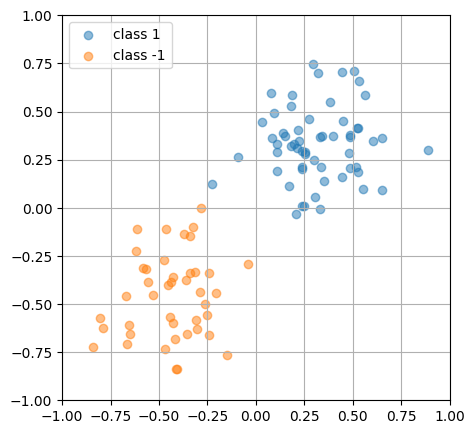

In [ ]:
dataset = 'dataset_1'
X_train = np.copy(datasets[dataset]['train']['x'])
y_train = np.copy(datasets[dataset]['train']['y'])

X_test = np.copy(datasets[dataset]['test']['x'])
y_test = np.copy(datasets[dataset]['test']['y'])

print("Training dataset has {0} datapoints".format(X_train.shape[0]))
print("Test dataset has {0} datapoints".format(X_test.shape[0]))

kernel = Linear()

Klog = kernel_kNN(5, kernel)
Klog.fit(X_train, y_train)

y_pred, _ = Klog.predict(X_test, y_test)

f1_score, precision = Klog.evaluate(y_pred, y_test)
print(f"The f1_score is {f1_score:.2f}, and the classifier's precision is {100*precision:.2f}%")

fig, ax = plt.subplots(1,1, figsize=(5, 5))
plotClassification(X_train, y_train, ax=ax)

The f1_score is 0.84, and the classifier's precision is 84.00%


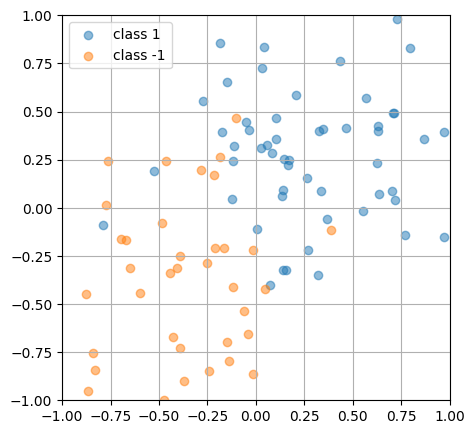

In [13]:
dataset = 'dataset_2'
X_train = np.copy(datasets[dataset]['train']['x'])
y_train = np.copy(datasets[dataset]['train']['y'])

X_test = np.copy(datasets[dataset]['test']['x'])
y_test = np.copy(datasets[dataset]['test']['y'])

kernel = RBF(gamma = 2)

Klog = kernel_kNN(10, kernel)
Klog.fit(X_train, y_train)

y_pred, precision = Klog.predict(X_test, y_test)

f1_score, precision = Klog.evaluate(y_pred, y_test)
print(f"The f1_score is {f1_score:.2f}, and the classifier's precision is {100*precision:.2f}%")

fig, ax = plt.subplots(1,1, figsize=(5, 5))
plotClassification(X_train, y_train, ax=ax)

The f1_score is 0.89, and the classifier's precision is 89.00%


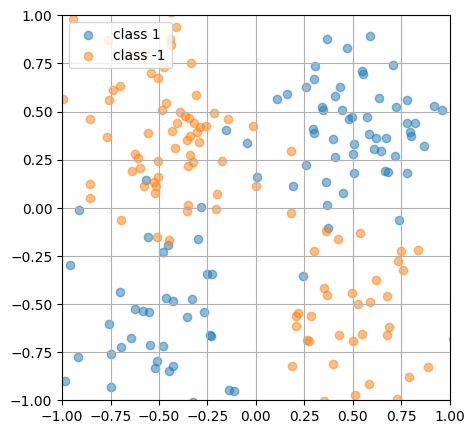

In [14]:
dataset = 'dataset_3'
X_train = np.copy(datasets[dataset]['train']['x'])
y_train = np.copy(datasets[dataset]['train']['y'])

X_test = np.copy(datasets[dataset]['test']['x'])
y_test = np.copy(datasets[dataset]['test']['y'])

kernel = RBF(gamma = 1)

Klog = kernel_kNN(10, kernel)
Klog.fit(X_train, y_train)

y_pred, precision = Klog.predict(X_test, y_test)

f1_score, precision = Klog.evaluate(y_pred, y_test)
print(f"The f1_score is {f1_score:.2f}, and the classifier's precision is {100*precision:.2f}%")

fig, ax = plt.subplots(1,1, figsize=(5, 5))
plotClassification(X_train, y_train, ax=ax)